In [1]:
from temgym_core.gaussian_action2D import make_gaussian, run_to_end
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.components import Detector
from temgym_core.utils import energy2wavelength
import jax
from temgym_core.utils import FresnelPropagator
import matplotlib.pyplot as plt
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
%matplotlib widget

run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)),
)


In [2]:
input_gaussian_one = make_gaussian(
    x=0,
    y=0.0,
    dx=1e-2,
    dy=0.0,
    waist_x=1e-7,
    waist_y=1e-7,
    voltage=1)

input_gaussian_two = make_gaussian(
    x=-1e-7,
    y=0.0,
    dx=0,
    dy=0.0,
    waist_x=1e-7,
    waist_y=1e-7,
    voltage=1)

input_window_width = 1e-6
Nx = Ny = 1500
input_aperture_pixel_size_x = input_window_width/Nx
input_aperture_pixel_size_y = input_window_width/Ny
input_aperture_grid = Detector(z=1e-5, pixel_size=(input_aperture_pixel_size_x, input_aperture_pixel_size_y), shape=(Nx, Ny))
extent = input_aperture_grid.extent


gaussian_image_one = evaluate_gaussians_gpu_kernel_wrapper(input_gaussian_one, input_aperture_grid)
gaussian_image_two = evaluate_gaussians_gpu_kernel_wrapper(input_gaussian_two, input_aperture_grid)

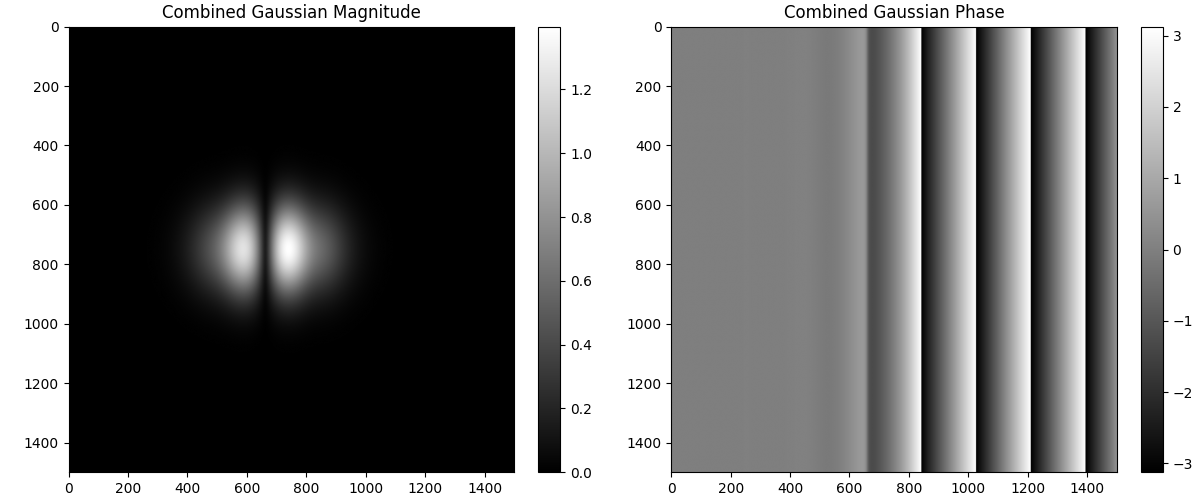

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axs[0].imshow(jnp.abs(gaussian_image_one + gaussian_image_two), cmap='gray')
axs[0].set_title('Combined Gaussian Magnitude')
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(jnp.angle(gaussian_image_one + gaussian_image_two), cmap='gray')
axs[1].set_title('Combined Gaussian Phase')
fig.colorbar(im1, ax=axs[1])

plt.show()

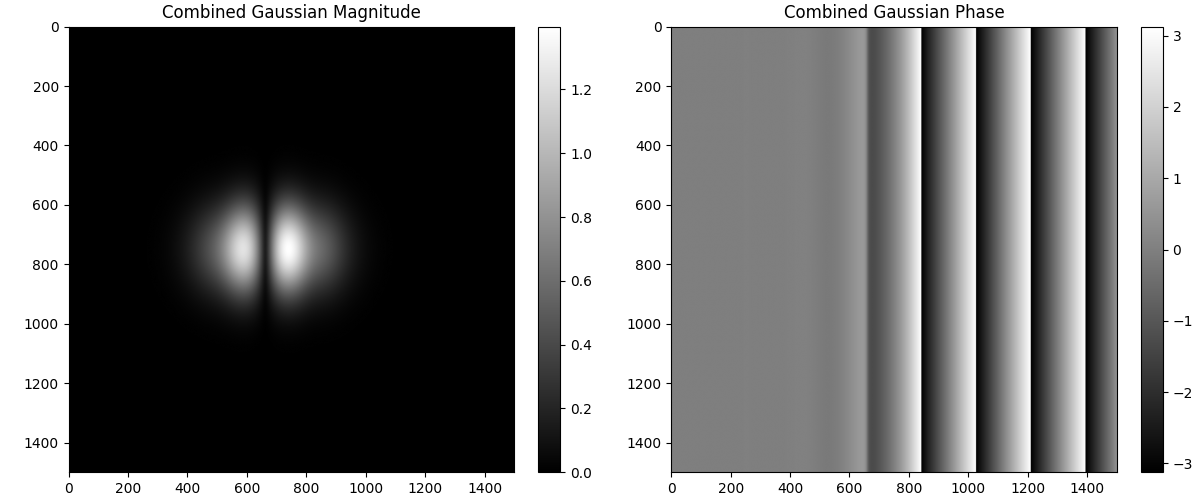

Relative L2 error vs analytic (scaled): 1.0796582121426987e-15


In [4]:
import jax.numpy as jnp

def make_detector_grid(detector):
    """Reconstruct an (X,Y) grid from a temgym_core.components.Detector."""
    (Nx, Ny) = detector.shape
    px, py = detector.pixel_size
    # Centered grid; with even sizes, 0 lies between the two central pixels.
    xs = (jnp.arange(Nx) - (Nx - 1) / 2.0) * px
    ys = (jnp.arange(Ny) - (Ny - 1) / 2.0) * py
    Y, X = jnp.meshgrid(xs, ys, indexing="xy")  # match evaluate_gaussians kernel indexing
    return Y, X

def gaussian_field_2d(X, Y, *, x0, y0, waist_x, waist_y, k, dx=0.0, dy=0.0,
                      amp=1.0, phase0=0.0):
    """
    Analytic 2D Gaussian at a plane z=0 with an (x,y) tilt (dx,dy).
    Conventions:
      - 'waist_*' is the 1/e amplitude radius (i.e., exp[-(x-x0)^2 / w^2])
      - 'dx, dy' are small slopes (radians), giving plane-wave factor exp[i k (dx x + dy y)]
    """
    env = jnp.exp(-((X - x0)**2 / (waist_x**2) + (Y - y0)**2 / (waist_y**2)))
    phase = k * (dx * X + dy * Y) + phase0
    return amp * env * jnp.exp(1j * phase)

def two_gaussians_analytic(detector,
                           g1_params, g2_params,
                           voltage_eV: float):
    """
    g*_params: dicts with keys {x0, y0, dx, dy, waist_x, waist_y, amp, phase0}
    """
    X, Y = make_detector_grid(detector)
    lam = energy2wavelength(voltage_eV)
    k = 2.0 * jnp.pi / lam

    E1 = gaussian_field_2d(X, Y, k=k, **g1_params)
    E2 = gaussian_field_2d(X, Y, k=k, **g2_params)
    return E1 + E2
# -----------------------------------------------------------------------------

# --- Build the analytic field for your exact test setup ----------------------
g1 = dict(x0=0.0,    y0=0.0, dx=1e-2, dy=0.0,
          waist_x=1e-7, waist_y=1e-7, amp=1.0, phase0=0.0)
g2 = dict(x0=-1e-7, y0=0.0, dx=0.0,  dy=0.0,
          waist_x=1e-7, waist_y=1e-7, amp=1.0, phase0=0.0)

E_analytic = two_gaussians_analytic(
    input_aperture_grid,
    g1_params=g1, g2_params=g2,
    voltage_eV=1.0
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axs[0].imshow(jnp.abs(E_analytic), cmap='gray')
axs[0].set_title('Combined Gaussian Magnitude')
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(jnp.angle(E_analytic), cmap='gray')
axs[1].set_title('Combined Gaussian Phase')
fig.colorbar(im1, ax=axs[1])

plt.show()

# --- Compare to your numerical result ----------------------------------------
E_numeric = gaussian_image_one + gaussian_image_two

# Best complex least-squares scaling (absorbs any overall amplitude/global phase):
alpha = (jnp.vdot(E_analytic, E_numeric) /
         jnp.vdot(E_analytic, E_analytic))
E_analytic_scaled = alpha * E_analytic

rel_err = jnp.linalg.norm(E_numeric - E_analytic_scaled) / jnp.linalg.norm(E_numeric)
print("Relative L2 error vs analytic (scaled):", float(rel_err))

# Suggested assertion for a unit test (tune threshold if your kernel uses a slightly different Gaussian convention):
assert rel_err < 1e-2


In [5]:
input_gaussian_one_two = make_gaussian(
    x=jnp.array([2e-2, -2e-2]),
    y=jnp.array([0.0, 0.0]),
    dx=jnp.array([-2.0e-2, 2.0e-2]),
    dy=jnp.array([0.0, 0.0]),
    z=jnp.array([0.0, 0.0]),
    waist_x=jnp.array([1e-2, 1e-2]),
    waist_y=jnp.array([1e-2, 1e-2]),
    voltage=jnp.array([1e-1, 1e-1])
)

multiplier = 100000
input_aperture_grid = Detector(z=1, pixel_size=(input_aperture_pixel_size_x * multiplier, input_aperture_pixel_size_y * multiplier), shape=(Nx, Ny))

extent = input_aperture_grid.extent
rays_out = run_to_end_vmapped(input_gaussian_one_two, (input_aperture_grid,))

gaussian_image_propagated = evaluate_gaussians_gpu_kernel_wrapper(rays_out, input_aperture_grid)


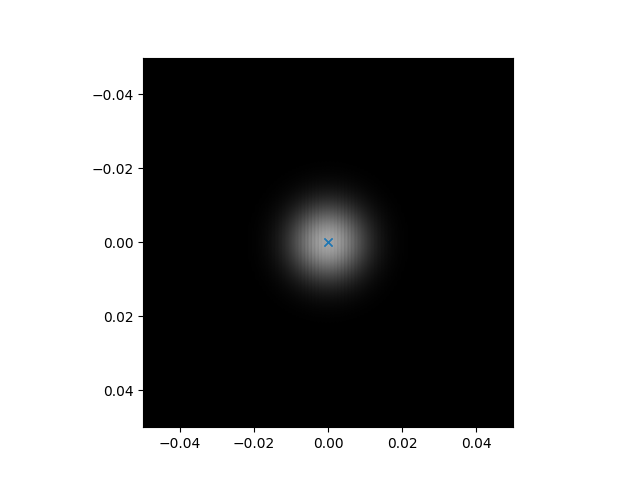

In [6]:
plt.figure()
plt.plot(rays_out.x, rays_out.y, 'x')
plt.imshow(jnp.abs(gaussian_image_propagated), cmap='gray', extent=extent)